# 01 — Corpus Exploration

Before we can model language statistically, we need to look at the raw
material: the text itself. This notebook loads the **NLTK Brown** and
**Reuters** corpora, tokenizes them, reports basic vocabulary and token
statistics, and visualises the word-frequency distribution to confirm it
follows **Zipf's law** — the empirical regularity that underpins why
n-gram models work (and why they struggle with rare words).


## 1. Imports & NLTK data

We rely on the helpers in `ngram.py` for loading and tokenizing, so the
exact same preprocessing is reused by the modeling notebook.

In [1]:
import nltk
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Make sure the corpora are available (no-op if already downloaded).
for pkg in ['brown', 'reuters', 'punkt', 'punkt_tab']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print('download warning:', pkg, e)

from ngram import load_sentences, build_vocab
print('Setup complete.')

Setup complete.


## 2. Load & tokenize

`load_sentences` reads sentences from both corpora, keeps only
alphanumeric tokens (dropping pure punctuation), and lowercases
everything. Lowercasing collapses `The`/`the` into one type, which
shrinks the vocabulary and gives the n-gram counts more data per word.

In [2]:
brown_sents = load_sentences(['brown'])
reuters_sents = load_sentences(['reuters'])
all_sents = brown_sents + reuters_sents

print(f'Brown sentences  : {len(brown_sents):>8,}')
print(f'Reuters sentences: {len(reuters_sents):>8,}')
print(f'Combined         : {len(all_sents):>8,}')
print()
print('Example tokenized sentence:')
print(all_sents[0][:20], '...')

Brown sentences  :   57,101
Reuters sentences:   54,711
Combined         :  111,812

Example tokenized sentence:
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took'] ...


## 3. Token & vocabulary statistics

A **token** is a single word occurrence; a **type** is a distinct word.
The ratio of tokens to types (and how the vocabulary keeps growing as we
read more text) is what makes language modeling hard — there is a long
tail of words seen only once or twice.

In [3]:
tokens = [w for sent in all_sents for w in sent]
counter = Counter(tokens)

n_tokens = len(tokens)
n_types = len(counter)
hapax = sum(1 for w, c in counter.items() if c == 1)

print(f'Total tokens (running words) : {n_tokens:>10,}')
print(f'Vocabulary size (word types) : {n_types:>10,}')
print(f'Type/token ratio             : {n_types / n_tokens:>10.4f}')
print(f'Hapax legomena (seen once)   : {hapax:>10,} '
      f'({100 * hapax / n_types:.1f}% of vocab)')
print()
print('Top 20 most frequent tokens:')
for w, c in counter.most_common(20):
    print(f'  {w:<10} {c:>8,}')

Total tokens (running words) :  2,465,187
Vocabulary size (word types) :     57,611
Type/token ratio             :     0.0234
Hapax legomena (seen once)   :     21,464 (37.3% of vocab)

Top 20 most frequent tokens:
  the         139,248
  of           73,191
  to           62,558
  and          54,501
  in           50,590
  a            48,298
  said         27,344
  for          23,271
  it           19,864
  mln          18,623
  that         18,134
  is           17,777
  on           15,985
  s            15,702
  was          15,631
  he           14,763
  vs           14,345
  with         13,468
  be           12,734
  from         12,587


The vocabulary is dominated by a handful of extremely common function
words (`the`, `of`, `to`, ...), while a large fraction of word *types*
appear only **once** (hapax legomena). This sparsity is exactly why
smoothing and `<unk>` handling matter — a model will constantly meet
words at test time that it saw rarely or never in training.

## 4. Per-corpus comparison

Brown is a *balanced* corpus of general American English (news, fiction,
academic, ...), whereas Reuters is *domain-specific* financial newswire.
Their vocabularies differ in character, which is useful: combining them
gives the model both everyday and specialised language.

In [4]:
def corpus_stats(sents, name):
    toks = [w for s in sents for w in s]
    c = Counter(toks)
    print(f'{name:<10} | sentences {len(sents):>7,} | '
          f'tokens {len(toks):>9,} | types {len(c):>7,}')
    return c

cb = corpus_stats(brown_sents, 'Brown')
cr = corpus_stats(reuters_sents, 'Reuters')

shared = set(cb) & set(cr)
print(f'\nShared vocabulary: {len(shared):,} types')
print('Reuters-only sample:', [w for w in cr if w not in cb][:10])

Brown      | sentences  57,101 | tokens   988,331 | types  41,018
Reuters    | sentences  54,711 | tokens 1,476,856 | types  30,951

Shared vocabulary: 14,358 types
Reuters-only sample: ['reuter', 'protectionist', 'mln', 'dlrs', 'tariffs', 'semiconductors', 'wouldn', 'matsushita', 'ltd', 'lt']


## 5. Zipf's law — the word-frequency distribution

**Zipf's law** states that the frequency of a word is roughly inversely
proportional to its rank: the 2nd most common word appears about half as
often as the 1st, the 3rd about a third as often, and so on. On a
log-log plot of frequency vs. rank this shows up as a near-straight line.
This heavy-tailed structure is the statistical foundation that n-gram
models exploit.

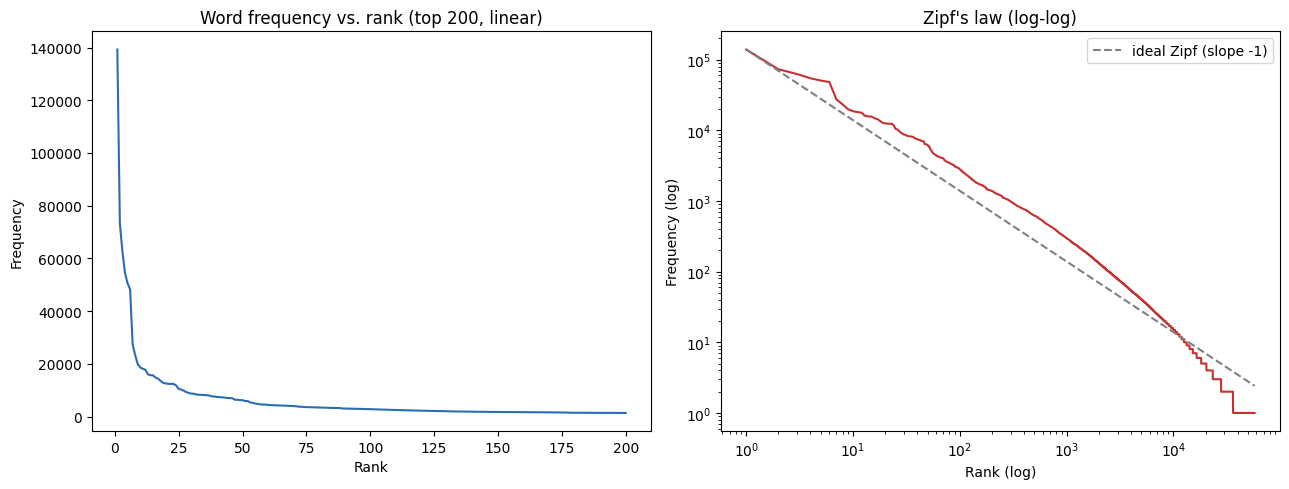

In [5]:
ranks = np.arange(1, n_types + 1)
freqs = np.array([c for _, c in counter.most_common()])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale — shows the brutal drop-off.
axes[0].plot(ranks[:200], freqs[:200], color='#2b6cb0')
axes[0].set_title('Word frequency vs. rank (top 200, linear)')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

# Log-log scale — Zipf's near-straight line.
axes[1].loglog(ranks, freqs, color='#c53030')
ideal = freqs[0] / ranks  # ideal Zipf slope -1 anchored at top word
axes[1].loglog(ranks, ideal, '--', color='gray', label='ideal Zipf (slope -1)')
axes[1].set_title("Zipf's law (log-log)")
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

The log-log curve hugs the ideal Zipf line over several orders of
magnitude, flattening only at the very head and bending down in the long
tail of rare words. This is textbook Zipfian behaviour.

## 6. Coverage — how much text the top-k words explain

Because a few words are so frequent, a small vocabulary covers most
running text. This justifies capping the vocabulary (mapping rare words
to `<unk>`) without losing much coverage.

Top    100 words cover  45.2% of all tokens
Top  1,000 words cover  72.3% of all tokens
Top  5,000 words cover  88.9% of all tokens
Top 10,000 words cover  93.9% of all tokens


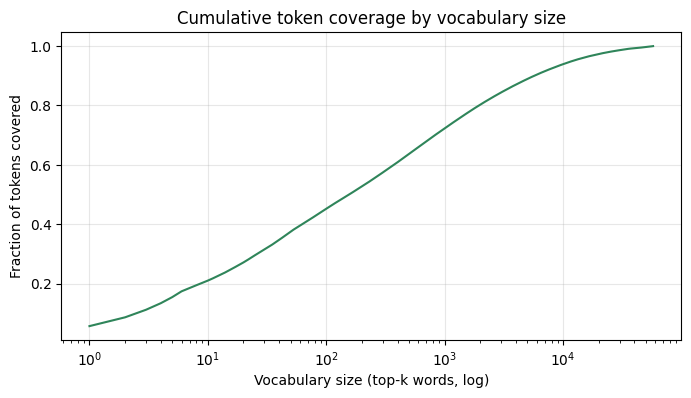

In [6]:
cum = np.cumsum(freqs) / n_tokens
for k in [100, 1000, 5000, 10000]:
    if k <= len(cum):
        print(f'Top {k:>6,} words cover {100 * cum[k - 1]:5.1f}% of all tokens')

plt.figure(figsize=(8, 4))
plt.plot(ranks, cum, color='#2f855a')
plt.xscale('log')
plt.title('Cumulative token coverage by vocabulary size')
plt.xlabel('Vocabulary size (top-k words, log)')
plt.ylabel('Fraction of tokens covered')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Effect of a minimum-count vocabulary cut

In the modeling notebook we keep only words seen at least `min_count`
times and map the rest to `<unk>`. Here we preview how aggressively that
prunes the long tail.

In [7]:
for mc in [1, 2, 5, 10]:
    v = build_vocab(all_sents, min_count=mc)
    print(f'min_count={mc:>2} -> vocabulary size {len(v):>8,}')

min_count= 1 -> vocabulary size   57,614
min_count= 2 -> vocabulary size   36,150


min_count= 5 -> vocabulary size   20,367
min_count=10 -> vocabulary size   13,316


## Summary

- Combined Brown + Reuters give us a large, mixed-domain corpus.
- The vocabulary is heavily **Zipfian**: a tiny head of frequent words,
  a huge tail of rare ones (a large share seen only once).
- A few thousand words cover the vast majority of running text, so an
  `<unk>`-capped vocabulary is both practical and well-justified.
- This sparsity is the central challenge the next notebook tackles with
  **smoothing** and **interpolation**.